In [1]:
# [1] Instalasi dependensi pendukung untuk modul pembelajaran (mglearn)
!pip install preamble mglearn

# [2] Memuat pustaka inti untuk komputasi numerik, analisis data, dan machine learning
import sys
import numpy as np
import scipy as sp
import pandas as pd
import sklearn

# [3] Memuat pustaka untuk kebutuhan visualisasi data
import matplotlib
import matplotlib.pyplot as plt
import IPython

# [4] Memuat modul khusus dan pengaturan awal dari buku pengantar ML
import mglearn
from preamble import *

# [5] Magic command agar output grafik langsung dirender di dalam Jupyter Notebook
%matplotlib inline

# [6] Verifikasi dan pencetakan versi pustaka untuk memastikan kompatibilitas environment
print(f"Versi Python: {sys.version}")
print(f"Versi Pandas: {pd.__version__}")
print(f"Versi Matplotlib: {matplotlib.__version__}")
print(f"Versi NumPy: {np.__version__}")
print(f"Versi SciPy: {sp.__version__}")
print(f"Versi IPython: {IPython.__version__}")
print(f"Versi Scikit-learn: {sklearn.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.9 MB/s eta 0:00:00
Versi Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Versi Pandas: 2.2.2
Versi Matplotlib: 3.10.0
Versi NumPy: 2.0.2
Versi SciPy: 1.16.3
Versi IPython: 7.34.0
Versi Scikit-learn: 1.6.1


# **NumPy**
NumPy merupakan pustaka fundamental dalam ekosistem Python yang dirancang untuk komputasi ilmiah. Keunggulan utamanya terletak pada manipulasi array multidimensi berkinerja tinggi serta ketersediaan berbagai fungsi matematis kompleks (seperti aljabar linier). Dalam konteks machine learning, representasi data secara umum menggunakan format array NumPy.

In [2]:
# Pembuatan array 2 dimensi menggunakan representasi NumPy
arr = np.array([[1, 2, 3], [4, 5, 6]])
print("Bentuk Array (ndarray):\n", arr)

Bentuk Array (ndarray):
 [[1 2 3]
 [4 5 6]]


# **SciPy**
SciPy adalah pustaka komplementer yang menyediakan ragam algoritma untuk optimasi matematis dan komputasi sains. Dalam machine learning, modul scipy.sparse sangat esensial karena memungkinkan pembuatan matriks jarang (sparse matrices). Format ini mengoptimalkan memori dengan hanya menyimpan elemen bernilai bukan nol (non-zero), sangat berguna ketika memproses dataset berskala besar yang didominasi oleh nilai nol.

In [3]:
from scipy import sparse

# 1. Membuat matriks identitas 2D standar menggunakan NumPy
matriks_identitas = np.eye(4)
print("Matriks NumPy 2D:\n", matriks_identitas)

# 2. Mengonversi matriks padat menjadi Compressed Sparse Row (CSR) matrix
matriks_jarang = sparse.csr_matrix(matriks_identitas)
print("\nMatriks Sparse CSR SciPy:\n", matriks_jarang)

# 3. Membangun representasi Coordinate Format (COO) matrix secara langsung
data_elemen = np.ones(4)
indeks_baris = np.arange(4)
indeks_kolom = np.arange(4)
matriks_coo = sparse.coo_matrix((data_elemen, (indeks_baris, indeks_kolom)))
print("\nMatriks Sparse dalam representasi COO:\n", matriks_coo)

Matriks NumPy 2D:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Matriks Sparse CSR SciPy:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0

Matriks Sparse dalam representasi COO:
 <COOrdinate sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


# **Matplotlib**
Matplotlib merupakan standar industri di Python untuk kebutuhan visualisasi data parametrik dan ilmiah. Visualisasi berperan penting dalam tahap Eksplorasi Data Analisis (EDA) untuk mengidentifikasi pola atau anomali sebelum tahap pemodelan.

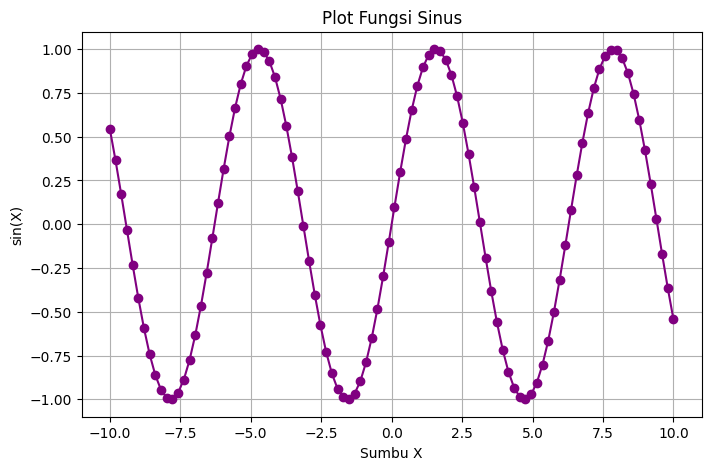

In [4]:
# Visualisasi fungsi matematis menggunakan Matplotlib
# Menghasilkan 100 titik data berjarak sama antara -10 hingga 10
x_axis = np.linspace(-10, 10, 100)
y_axis = np.sin(x_axis)

plt.figure(figsize=(8, 5))
plt.plot(x_axis, y_axis, marker="o", linestyle="-", color="purple")
plt.title("Plot Fungsi Sinus")
plt.xlabel("Sumbu X")
plt.ylabel("sin(X)")
plt.grid(True)
plt.show()

# **Pandas**
Pandas adalah pustaka yang dikhususkan untuk manipulasi dan pembersihan data tabular. Struktur data utamanya, yaitu DataFrame, dirancang menyerupai tabel relasional yang fleksibel, di mana setiap kolom dapat menampung tipe data yang berbeda (heterogeneous data). Hal ini berbeda dengan NumPy array yang mewajibkan keseragaman tipe data (homogeneous).

In [5]:
import pandas as pd

# Representasi data mentah dalam bentuk kamus (dictionary)
kamus_data = {
    'Nama': ["John", "Anna", "Peter", "Linda"],
    'Lokasi' : ["New York", "Paris", "Berlin", "London"],
    'Umur' : [24, 13, 53, 33]
}

# Transformasi dictionary menjadi objek Pandas DataFrame
df_orang = pd.DataFrame(kamus_data)
display(df_orang)

# Implementasi filter logika: Ekstraksi data individu berusia di atas 30 tahun
df_filter = df_orang[df_orang.Umur > 30]
display(df_filter)

,Nama,Lokasi,Umur
0,John,New York,24
1,Anna,Paris,13
2,Peter,Berlin,53
3,Linda,London,33


,Nama,Lokasi,Umur
2,Peter,Berlin,53
3,Linda,London,33


# **2. Studi Kasus: Klasifikasi Spesies Bunga Iris**

## Eksplorasi Dataset (Data Discovery)
Dataset Bunga Iris merupakan rujukan standar (benchmark) dalam pengenalan pola algoritma klasifikasi. Dataset ini merekam empat fitur morfologis dari 150 sampel bunga yang terbagi ke dalam tiga spesies berbeda. Dalam terminologi machine learning, baris data merepresentasikan sampel (samples), sedangkan kolom pengukuran disebut fitur (features).

In [6]:
from sklearn.datasets import load_iris

# Memuat dataset Iris bawaan dari pustaka scikit-learn
iris_dataset = load_iris()

# Inspeksi metadata dan dimensi dataset
print("Atribut kunci (keys):", list(iris_dataset.keys()))
print("Nama target (kelas spesies):", iris_dataset['target_names'])
print("Daftar fitur pengukuran:", iris_dataset['feature_names'])

print("\nDimensi matriks fitur (X):", iris_dataset['data'].shape)
print("Dimensi vektor target (y):", iris_dataset['target'].shape)

Atribut kunci (keys): ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Nama target (kelas spesies): ['setosa' 'versicolor' 'virginica']
Daftar fitur pengukuran: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Dimensi matriks fitur (X): (150, 4)
Dimensi vektor target (y): (150,)


# **Pemisahan Data (Train-Test Split)**
Pemisahan Data (Train-Test Split) Untuk memvalidasi tingkat generalisasi dari sebuah model, dataset wajib dipartisi menjadi dua himpunan independen: Data Latih (Training Set) untuk mengoptimasi model, dan Data Uji (Testing/Hold-out Set) untuk mengevaluasi performa prediksinya. Evaluasi menggunakan data latih tidak direkomendasikan karena dapat memicu masalah overfitting (model hanya "menghafal" data).Secara matematis dan konvensi scikit-learn, matriks fitur dinotasikan dengan huruf kapital $X$ (karena berupa array 2D/matriks), sedangkan label kelas dinotasikan dengan huruf kecil $y$ (karena berupa array 1D/vektor), merepresentasikan fungsi matematis $y = f(X)$.

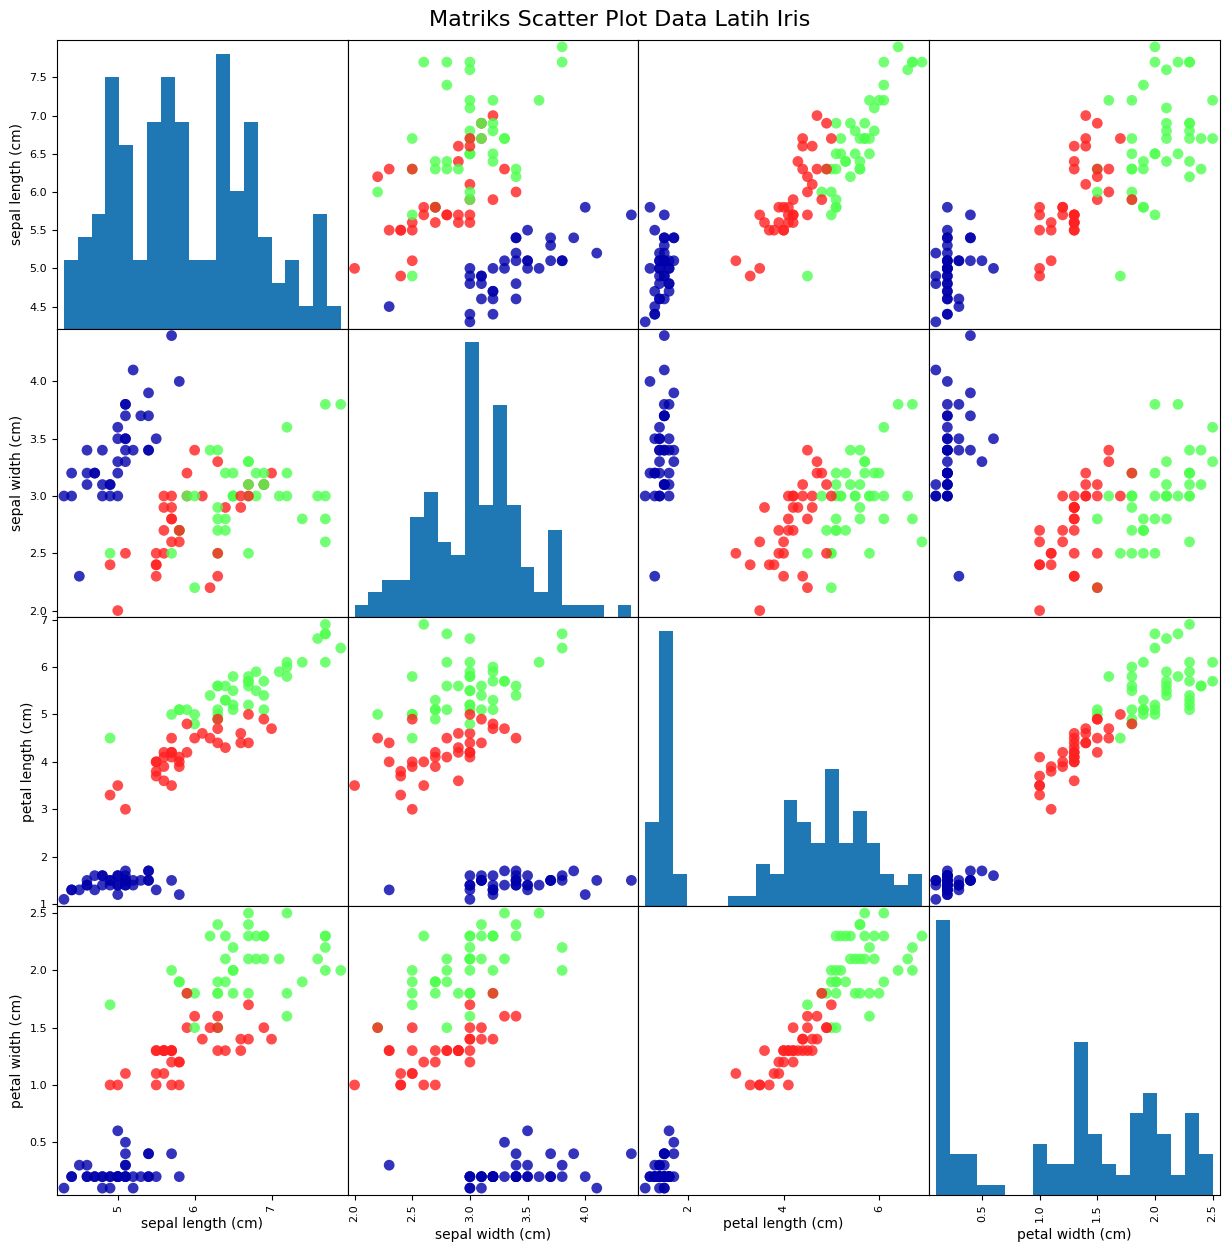

In [7]:
from sklearn.model_selection import train_test_split

# Mempartisi dataset dengan rasio standar 75% data latih dan 25% data uji
# Parameter random_state digunakan untuk menjamin reproduksibilitas pengacakan data
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0
)

# Visualisasi sebaran data latih menggunakan scatter matrix untuk analisis korelasi antar fitur
df_iris = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
pd.plotting.scatter_matrix(
    df_iris, c=y_train, figsize=(15, 15), marker='o',
    hist_kwds={'bins': 20}, s=60, alpha=.8, cmap=mglearn.cm3
)
plt.suptitle("Matriks Scatter Plot Data Latih Iris", y=0.9, fontsize=16)
plt.show()

# **Pemodelan menggunakan K-Nearest Neighbors (KNN)**
Pendekatan K-Nearest Neighbors beroperasi dengan mengidentifikasi kedekatan metrik antara titik data uji baru dengan titik data yang ada di training set. Algoritma ini akan memprediksi kelas berdasarkan mayoritas kelas dari sejumlah $K$ tetangga terdekatnya.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Inisialisasi arsitektur model KNN dengan konfigurasi 1 tetangga terdekat (K=1)
model_knn = KNeighborsClassifier(n_neighbors=1)

# 2. Proses pelatihan model (fitting) menggunakan himpunan data latih
model_knn.fit(X_train, y_train)

# 3. Simulasi inferensi pada observasi baru
sampel_baru = np.array([[5, 2.9, 1, 0.2]])
prediksi_kelas = model_knn.predict(sampel_baru)
print("Hasil Prediksi Spesies Data Baru:", iris_dataset['target_names'][prediksi_kelas][0])

# 4. Evaluasi performa model secara komprehensif menggunakan himpunan data uji
y_prediksi = model_knn.predict(X_test)
akurasi_model = model_knn.score(X_test, y_test)

print(f"\nAkurasi Evaluasi Uji (Metode KNN.score): {akurasi_model:.2f} atau setara dengan {akurasi_model*100:.0f}%")

Hasil Prediksi Spesies Data Baru: setosa

Akurasi Evaluasi Uji (Metode KNN.score): 0.97 atau setara dengan 97%
